In [1]:
import numpy as np
import torch

from torchgpe.bec2D import Gas
from torchgpe.bec2D.potentials import LinearPotential, Union, Callable, any_time_dependent_variable, time_dependent_variable
from torchgpe.utils.potentials import NonLinearPotential

import sys
import importlib
sys.path.append('..')

import two_component_variable_gas
importlib.reload(two_component_variable_gas)
from two_component_variable_gas import TwoComponentGas

import peden_two_state_3D
importlib.reload(peden_two_state_3D)
from peden_two_state_3D import set_two_component_molecular_mass, Trap3D, PedenDirectDDI3D, initialize_two_component_gaussian, print_imaginary_time_stiffness
from peden_two_state_3D import plot_central_x_slices, plot_xy_density, plot_xz_density, DEBYE_TO_C_M, print_beta_and_D_from_gas_stark_shift, rms_rho_over_ellz

/users/bohn/kexu8775/DielectricBEC/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mass_amu = 220.0

# Quasi-2D / pancake trap.
# Frequencies must be angular frequencies, rad/s.
omega_x = 2 * np.pi * 400
omega_y = 2 * np.pi * 400
omega_z = 2 * np.pi * 4000

trap = Trap3D(
    omegax=omega_x,
    omegay=omega_y,
    omegaz=omega_z,
)

hbar = 1.054571817e-34
amu_to_kg = 1.6605e-27

ellz = np.sqrt(hbar/mass_amu/omega_z/amu_to_kg)
print(ellz)

1.0717348922623537e-07


In [3]:
N_up = int(50)
N_down = int(50)

gas = TwoComponentGas(
    element="87Rb",
    N_particles=(N_up, N_down),
    N_grid=64,
    grid_size=(3000e-9, 3000e-9, 1000e-9),
    adimensionalization_length=ellz,
    device="cuda",
)

set_two_component_molecular_mass(gas, mass_amu=mass_amu)

3.6531859516239997e-25

Initial Gaussian widths
-----------------------
sigma_x = 0.3389 um
sigma_y = 0.3389 um
sigma_z = 0.1072 um
tensor([3.1235e-09, 3.5448e-10], dtype=torch.float64)


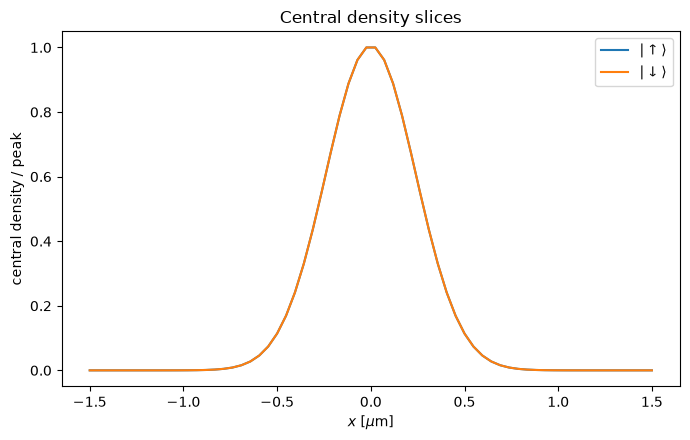

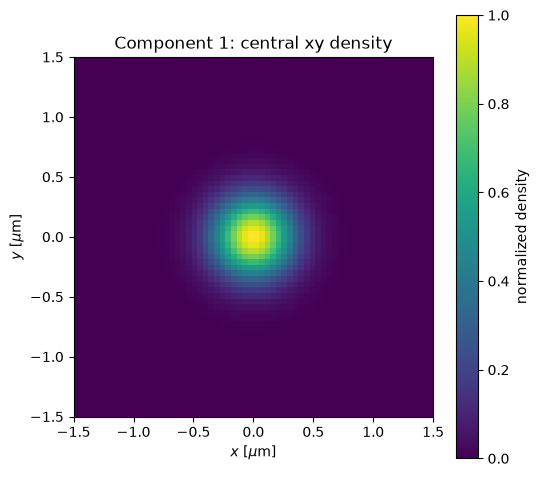

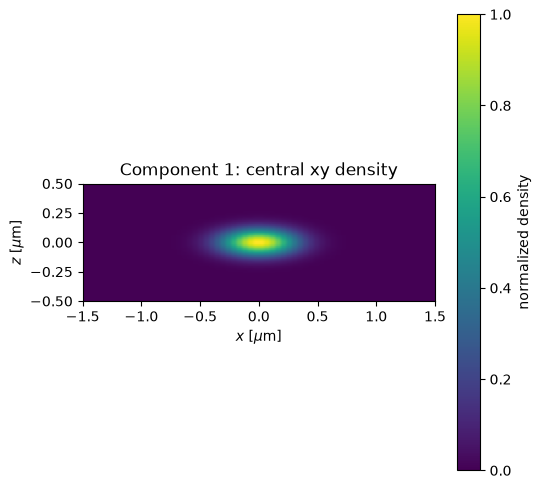

In [4]:
# Initialize.
initialize_two_component_gaussian(
    gas,
    omega_x=omega_x,
    omega_y=omega_y,
    omega_z=omega_z,
)

density = torch.abs(gas.psi[0]) ** 2

edge_max = torch.tensor([density[0,:,:].max(), density[:,:,0].max()])

print(edge_max / density.max().item())

plot_central_x_slices(gas, normalize=True)
plot_xy_density(gas, component=0, normalize=True)
plot_xz_density(gas, component=0, normalize=True)

In [5]:
import single_molecule_hamiltonian
importlib.reload(single_molecule_hamiltonian)
from single_molecule_hamiltonian import SingleMoleculeHamiltonian

from itp_energy_monitor import ground_state_energy_converged

import pickle
from IPython.display import clear_output

import scipy.constants as const

initialize_two_component_gaussian(
    gas,
    omega_x=omega_x,
    omega_y=omega_y,
    omega_z=omega_z,
)

# detuning (zero field separation)
Omega = 2 * omega_z

for beta in [1]:
    for D in np.arange(0, 2500, 25):
        print("D = ", D)
        # stark shift energy difference (d0E is half of this)
        delta = 2 * beta * omega_z

        single_molecule = SingleMoleculeHamiltonian(
            delta=delta,
            Omega=Omega,
            phase=0.0,
        )

        d0_debye = np.sqrt(D / gas.N_total * (3 * const.epsilon_0) * (hbar * omega_z) * (ellz ** 3)) / DEBYE_TO_C_M
        ddi = PedenDirectDDI3D(
            d_up_debye=+d0_debye,
            d_down_debye=-d0_debye,
            polarization=(0.0, 0.0, 1.0),
        )

        # ddi.set_gas(gas)
        # ddi.on_propagation_begin()
        # ddi.print_couplings()

        # params = print_beta_and_D_from_gas_stark_shift(
        #     gas,
        #     d_debye=d0_debye,
        #     stark_shift_Hz=2*delta/(2*np.pi),       # dE/h = 500 Hz
        #     Delta_Hz=Omega/(2*np.pi),            # Delta/h = 1000 Hz
        #     omega_z_rad_s=2*np.pi*4000,
        # )

        # print_imaginary_time_stiffness(
        #     gas=gas,
        #     trap=trap,
        #     ddi=ddi,
        #     single_molecule=single_molecule,
        #     time_step=-1e-6j,
        # )

        monitor = ground_state_energy_converged(
            gas,
            potentials=[trap, ddi, single_molecule],
            time_step=-1e-6j,
            N_iterations=50_000,
            rtol=1e-12,
            compute_every=10,
            print_every=100,
            csv_path=f"saved/beta{beta:.2f}/beta{beta:.2f}_D{int(D)}.csv"
        )

        with open(f"saved/beta{beta:.2f}/beta{beta:.2f}_D{int(D)}.pkl", "wb") as f:
            data = {
                "gas" : gas,
                "summary" : monitor.summary()
            }
            pickle.dump(data, f)

        psi = gas.psi

        rho0 = rms_rho_over_ellz(gas, component=0)
        rho1 = rms_rho_over_ellz(gas, component=1)

        print(rho0, rho1)
        
        with open(f"compress/beta{beta:.2f}/beta{beta:.2f}_D{int(D)}.pkl", "wb") as f:
            data = {
                "psi" : psi.detach().cpu(),
                "rho" : (rho0, rho1),
                "summary" : monitor.summary()
            }
            pickle.dump(data, f)

        if rho0 < 1 or rho1 < 1:
            break

        clear_output(wait=True)


D =  100
Single-molecule Hamiltonian diagnostics
--------------------------------------
H_dim eigenvalues: [-1.41424684  1.41424684]
H_dim eigenvalue spread: 2.8284936713979794
iter        0 | E=-7.2067931277051123e-01 | dE/E=--- | E_Hz=-2.882649429e+03 | T=2.630956047e-01 | V=3.478949257e-01 | DDI=7.301905853e-02 | Hsm=-1.404688902e+00 | f=(0.185414,0.814586)


Ground state:   0%|          | 102/50000 [00:10<1:23:59]

iter      100 | E=-7.2188805719304316e-01 | dE/E=9.425e-06 | E_Hz=-2.887484293e+03 | T=2.590026114e-01 | V=3.544362393e-01 | DDI=6.386750849e-02 | Hsm=-1.399194416e+00 | f=(0.196188,0.803812)


Ground state:   0%|          | 202/50000 [00:20<1:23:49]

iter      200 | E=-7.2192954754178584e-01 | dE/E=3.567e-06 | E_Hz=-2.887650250e+03 | T=2.587407171e-01 | V=3.551786387e-01 | DDI=6.357615888e-02 | Hsm=-1.399425062e+00 | f=(0.195774,0.804226)


...

iter     1100 | E=-7.2195410550139227e-01 | dE/E=1.108e-09 | E_Hz=-2.887748480e+03 | T=2.583443663e-01 | V=3.563791853e-01 | DDI=6.311052449e-02 | Hsm=-1.399788182e+00 | f=(0.195115,0.804885)


Ground state:   2%|▏         | 1202/50000 [02:01<1:22:11]

iter     1200 | E=-7.2195409856283743e-01 | dE/E=8.330e-10 | E_Hz=-2.887748452e+03 | T=2.583423691e-01 | V=3.563853611e-01 | DDI=6.310816158e-02 | Hsm=-1.399789990e+00 | f=(0.195112,0.804888)


Ground state:   3%|▎         | 1294/50000 [02:10<1:22:04]


KeyboardInterrupt: 

In [6]:
d0_debye

np.float64(0.43906870801871356)

/home/bohn/kexu8775/DielectricBEC/peden_two_state_3D.py:433: RuntimeWarning: invalid value encountered in divide
  line_down = line_down / np.max(line_down)


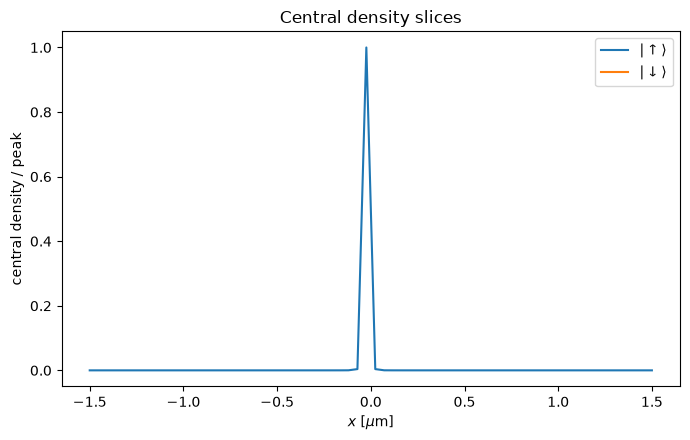

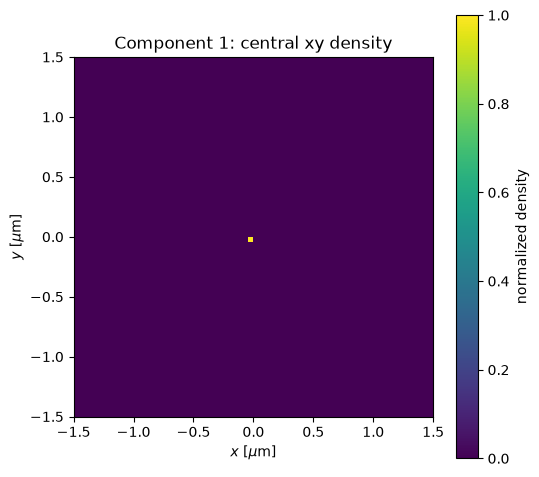

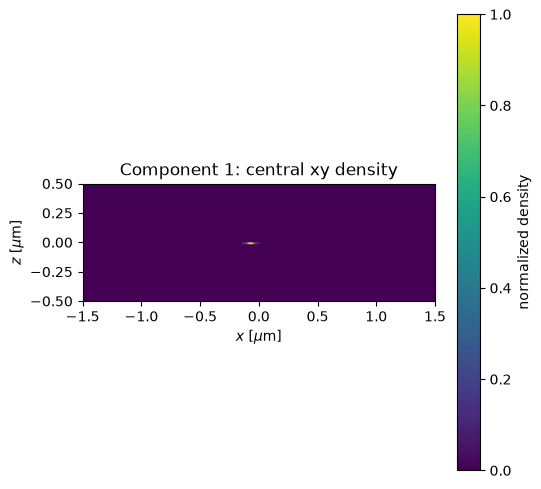

In [7]:
plot_central_x_slices(gas, normalize=True)
plot_xy_density(gas, component=0, normalize=True)
plot_xz_density(gas, component=0, normalize=True)